# Structural Estimation using DC-EGM for Education Level 1

## Dependencies, Packages & Roots

### Magics

In [1]:
%reload_ext autoreload
%autoreload 2

### Project Paths

In [2]:
from pathlib import Path
import sys
import importlib

# Change this depending on notebook location:
# 0 = notebook is 1 folder inside project root, e.g. dp_termpaper/edu1
# 1 = notebook is 2 folders inside project root, e.g. dp_termpaper/data/moments
# 2 = notebook is 3 folders inside project root
amount_of_levels = 0

DIR = Path.cwd().resolve().parents[amount_of_levels]

if str(DIR) not in sys.path:
    sys.path.insert(0, str(DIR))

import project_paths as pp
from project_imports import *

importlib.reload(pp)
jax.config.update("jax_enable_x64", True)

## Load Data 

In [3]:
###############################################################
#### Define which education level you want to estimate for ####
###############################################################

education_level_file = pp.MOMENTS_DIR / "moments_udd1.txt"
# education_level_file = pp.MOMENTS_DIR / "moments_udd2.txt"
# education_level_file = pp.MOMENTS_DIR / "moments_udd3.txt"

MORTALITY = pp.DATA_DIR / "mortality.xlsx"

In [4]:
PARAM_FILE = pp.STRUCTURAL_RESULTS_DIR / "optimized_own_params_udd1.txt"
params = load_params_txt(PARAM_FILE)
# params

In [5]:
# Read CSV
df_edu = pd.read_csv(education_level_file)
# read mortality and discard seoncd and third column
df_mort = pd.read_excel(MORTALITY, sheet_name="DOD", usecols=[0, 3])

# 2) standardize colomn name and remove _FREQ_ column
# Iterate over DataFrames (if there are multiple DataFrames to process)
for data_frame in [df_edu]:
    # Rename ALDER → age
    if "ALDER" in data_frame.columns:
        data_frame.rename(columns={"ALDER": "age"}, inplace=True)
    # Remove _FREQ_-column if it exists
    # if "_FREQ_" in data_frame.columns:
    #     data_frame.drop(columns=["_FREQ_"], inplace=True)
# drop var_wage, skew_wage and pens
df_edu.drop(columns=["var_wage", "skew_wage", "pens"], inplace=True)
# df_edu

# Estimation of wage parameters

In [7]:
##################################################################
###################### OLS ESTIMATION ############################
##################################################################

def wage_estimation(estimator="ols", save=True):
    estimator = estimator.lower()

    if estimator not in ["ols", "wls"]:
        raise ValueError("estimator must be either 'ols' or 'wls'.")

    files = {
        1: pp.MOMENTS_DIR / "moments_udd1.txt",
        2: pp.MOMENTS_DIR / "moments_udd2.txt",
        3: pp.MOMENTS_DIR / "moments_udd3.txt",
    }

    dfs = {
        udd: pd.read_csv(path)
        for udd, path in files.items()
    }

    models = {}
    betas = {}

    for udd, df in dfs.items():
        df = df.copy()

        if "ALDER" in df.columns:
            df.rename(columns={"ALDER": "age"}, inplace=True)

        df["log_wage"] = np.log(df["avg_wage"])

        X = sm.add_constant(
            np.column_stack((df["age"], df["age"] ** 2))
        )

        y = df["log_wage"]

        if estimator == "ols":
            model = sm.OLS(y, X, missing="drop").fit()

        elif estimator == "wls":
            if "_FREQ_" not in df.columns:
                raise ValueError(f"_FREQ_ missing for education group {udd}")

            weights = df["_FREQ_"]
            model = sm.WLS(y, X, weights=weights, missing="drop").fit()

        beta0, beta1, beta2 = model.params

        models[udd] = model
        betas[udd] = {
            "beta0": beta0,
            "beta1": beta1,
            "beta2": beta2,
        }

        df["predicted"] = np.exp(
            beta0 + beta1 * df["age"] + beta2 * df["age"] ** 2
        )

        dfs[udd] = df

        print(
            f"{estimator.upper()} UDD {udd}: "
            f"β0={beta0:.4f}, β1={beta1:.4f}, β2={beta2:.4f}"
        )

    return betas, models, dfs

In [14]:
betas_ols = wage_estimation(estimator="ols")
print("\n")
betas_wls = wage_estimation(estimator="wls")

OLS UDD 1: β0=-6.8961, β1=0.0272, β2=-0.0002
OLS UDD 2: β0=-7.3453, β1=0.0522, β2=-0.0004
OLS UDD 3: β0=-7.7211, β1=0.0742, β2=-0.0006


WLS UDD 1: β0=-6.7887, β1=0.0254, β2=-0.0002
WLS UDD 2: β0=-7.3382, β1=0.0552, β2=-0.0005
WLS UDD 3: β0=-7.5498, β1=0.0708, β2=-0.0006


In [24]:
# Choose your estimator
beta0, beta1, beta2 = wage_estimation(estimator="ols")
# beta0, beta1, beta2 = wage_estimation(estimator="wls")

OLS UDD 1: β0=-6.8961, β1=0.0272, β2=-0.0002
OLS UDD 2: β0=-7.3453, β1=0.0522, β2=-0.0004
OLS UDD 3: β0=-7.7211, β1=0.0742, β2=-0.0006


# ====================================================================================================================

# Solving and simulating the model

### Initiatal parameters - some are estimated above, the rest to be structuraly estimated

In [25]:
params_initial = {}
params_initial["interest_rate"] = 0.01
params_initial["income_shock_mean"] = 0.000 # income shock mean
params_initial["income_shock_std"] = 0.15721008127024574 # income shock scale
params_initial["taste_shock_scale"] = 1.0966242697158703 # taste shock scale

# discount factor
params_initial["discount_factor"] = 0.90535854

# parameters for the utility function
params_initial["rho"]=0.50092644 #0.76492381

# disutility of each hours choice
params_initial["gamma"]=jnp.array([0.82253966,1.5360604,1.93859858,1.25922689]) 

# wage parameters
params_initial["beta0"]=beta0
params_initial["beta1"]=beta1
params_initial["beta2"]=beta2

# Age component disutility
params_initial["kappa1"]=0.01531974
params_initial["kappa2"]=0.00216552

# transsition cost
params_initial["phi"]=0.94614399

# mortality parameters
params_initial["alpha1"]=0.000417
params_initial["alpha2"]=0.099277

# bequest parameters
params_initial["b_scale"]=1.2133177
params_initial["xi"]=0.26926199

# labor market parameters
params_initial["eta_edu"]=0.43848

params=params_initial.copy()

## Options for model - Choices and states

In [26]:
n_periods = 55
labour_choices = np.arange(5) # 5 choices
alpha1, alpha2 = np.loadtxt(pp.STRUCTURAL_RESULTS_DIR/ "mortality_params.txt")

model_config = {
    "n_periods": n_periods,
    "choices": labour_choices, # 5 choices
    "n_quad_points": 5,
    "continuous_states": {
        "assets_end_of_period": np.linspace(0, 50, 20),
        "experience": jnp.linspace(0, 1, 5).astype(float) # 1 experince grid point, if experience can only go up by a year - more points if it is a fraction based on hours worked
        },
    "stochastic_states": {
        "survival": [0, 1],
    }
    }

model_specs = {
    "n_periods": n_periods,
    "labour_choices": labour_choices, # 5 choices
    "hours": jnp.array([0,250,750,1300,1900]), #list 
    "max_hours": 1500,
    "start_age": 30,
    "tax_threshold1": 0.480,
    "tax_threshold2": 5.698,
    "tax_base_rate": 0.38,
    "tax_top_rate": 0.5,
    "retirement_age": 67,
    "oap_base_amount":0.80328,
    "oap_max_supplement": 0.92940,
    "supp_threshold": 0.79300,
    "oap_threshold": 3.3592,
    "supp_reduction_rate": 0.309,
    "oap_reduction_rate": 0.3,
    "alpha1": alpha1, # independently estimated parameter for survival probability
    "alpha2": alpha2,  # independently estimated parameter for survival probability
    "max_init_experience": 5,
    "max_ret_period": 45, # Age 75
    "min_ret_period": 30, # Age 60
}
stochastic_states_transitions = {
    "survival": prob_survival
}

### Setup the model

In [27]:
model = dcegm.setup_model(
    model_config=model_config,
    model_specs=model_specs,
    utility_functions=utility_functions,
    utility_functions_final_period=final_period_utility,
    budget_constraint=budget_dcegm_initial,
    state_space_functions=create_state_space_function_dict(),
    stochastic_states_transitions=stochastic_states_transitions,
)

State specific choice set not provided. Assume all choices are available in every state.
Update function for state space not given. Assume states only change with an increase of the period and lagged choice.
Starting state space creation
State space created.

Starting state-choice space creation and child state mapping.
State, state-choice and child state mapping created.

Start creating batches for the model.
The batch size of the backwards induction is  25
Model setup complete.



### Initial values for simulating. 

In [28]:
# Select number of individuals for simulation
#Debug level
# n_individuals = 10

# Optimal level
n_individuals = 100000

seed = 132
key = jax.random.PRNGKey(0)
n = n_individuals       

# hours mapping for simulation
hours_map = {0: 0, 1: 250, 2: 750, 3: 1300, 4: 1900}

#age for simulation
start_age = model_specs["start_age"] 

# distribution of initial choices
labels = jnp.array([0, 1, 2, 3, 4], dtype=jnp.int32)
probs  = jnp.array([0.259155, 0.118310, 0.108099, 0.108451, 0.405986])  # sums to 1.0

lagged_choice = jax.random.choice(
    key,
    a       = labels,
    shape   = (n,),
    p       = probs,
    replace = True
)

# set initial states for each individual
states_initial = {
    "period": jnp.zeros(n_individuals, dtype=jnp.int32),      # Every individual starts at period 0 (age 30)
    "lagged_choice": lagged_choice,  # Every individual starts with choice 3 (work fulltime)
    "experience": jnp.full(n_individuals, 1).astype(float),  # Every individual starts with 5 years of experience
    "survival": jnp.ones(n_individuals, dtype=jnp.int32), # Every individual starts with 1 (alive)
    "assets_begin_of_period": jnp.full(n_individuals, 0.505047) # Every individual starts with 59k wealth - to be adjusted based on the actual moments
}

## Plots

In [29]:
labels = {
    "avg_wealth": "Average Wealth",
    "hours_0": "Unemployed",
    "hours_1": "Below 10 hours",
    "hours_2": "10-20 hours",
    "hours_3": "20-30 hours",
    "hours_4": "Above 30 hours",
    "avg_hours": "Average Hours",
    "prob_work": "Employment Rate",
    "avg_wage": "Average Wage",
    "avg_experience": "Average Experience",
    "work_work": "Work to Work Transition Rate",
    "nowork_nowork": "No Work to No Work Transition Rate",
}

scales = {
    "avg_wealth": 100_000,
    "avg_wage": 100_000,
}

### Load params, solve model and simulate juts once

In [30]:
params = load_params_txt(pp.STRUCTURAL_RESULTS_DIR / "optimized_params_udd1.txt")
# If you want to see Frederiks original parameters, load optimized_params_udd1.txt instead
params["gamma"] = jnp.asarray(params["gamma"])

model_solved = model.solve(params)
sim = model_solved.simulate(
    states_initial=states_initial,
    seed=seed,
)

Saved C:\Users\Nashw\Studiet\polit\2. Semester\DynamicProgramming\Thesis\dp_termpaper\4. Results\plots\simulation\wage_estimation\prob_work_over_age.png
Saved C:\Users\Nashw\Studiet\polit\2. Semester\DynamicProgramming\Thesis\dp_termpaper\4. Results\plots\simulation\wage_estimation\hours_0_over_age.png
Saved C:\Users\Nashw\Studiet\polit\2. Semester\DynamicProgramming\Thesis\dp_termpaper\4. Results\plots\simulation\wage_estimation\hours_1_over_age.png
Saved C:\Users\Nashw\Studiet\polit\2. Semester\DynamicProgramming\Thesis\dp_termpaper\4. Results\plots\simulation\wage_estimation\hours_2_over_age.png
Saved C:\Users\Nashw\Studiet\polit\2. Semester\DynamicProgramming\Thesis\dp_termpaper\4. Results\plots\simulation\wage_estimation\hours_3_over_age.png
Saved C:\Users\Nashw\Studiet\polit\2. Semester\DynamicProgramming\Thesis\dp_termpaper\4. Results\plots\simulation\wage_estimation\hours_4_over_age.png
Saved C:\Users\Nashw\Studiet\polit\2. Semester\DynamicProgramming\Thesis\dp_termpaper\4. Res

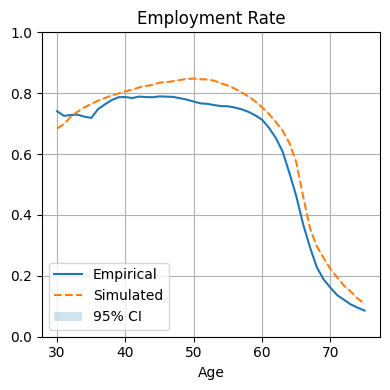

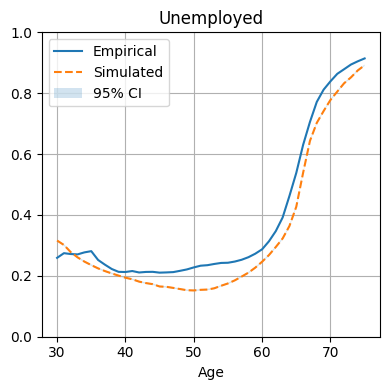

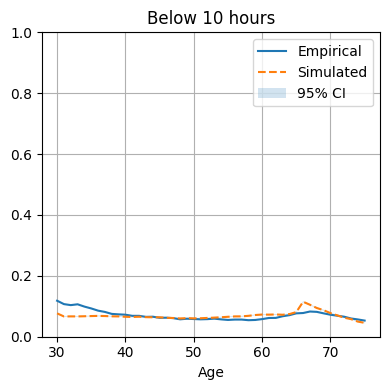

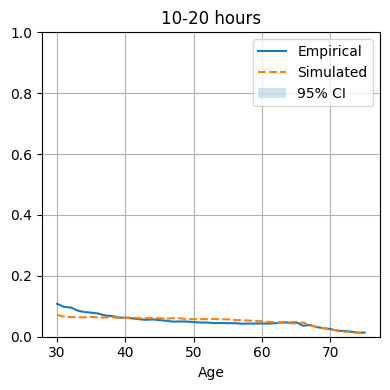

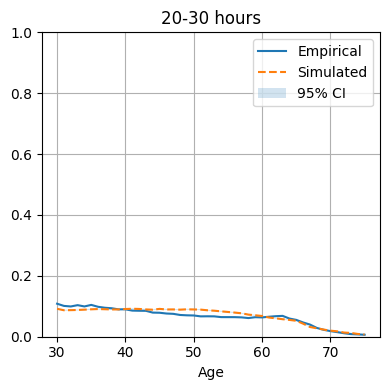

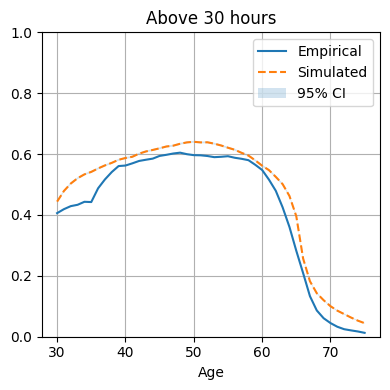

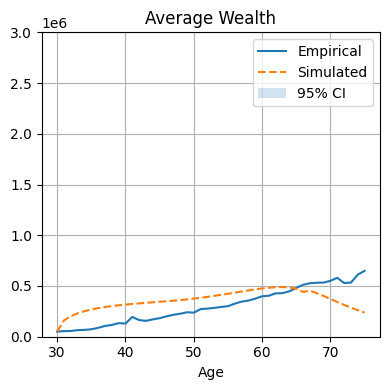

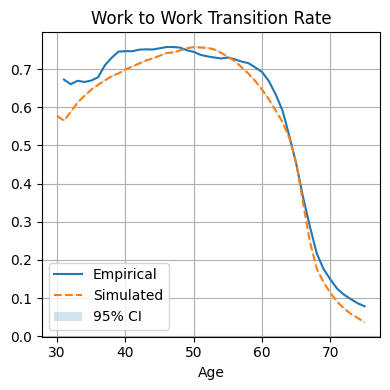

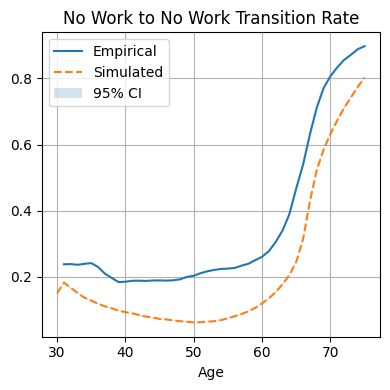

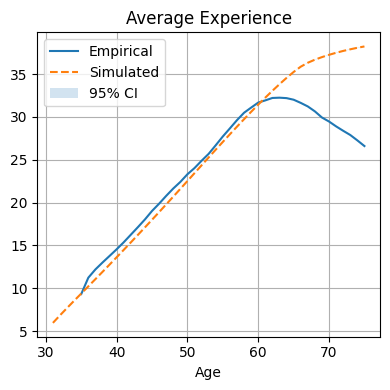

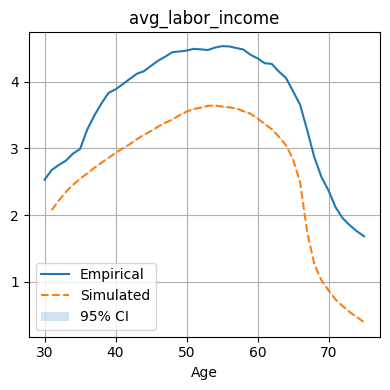

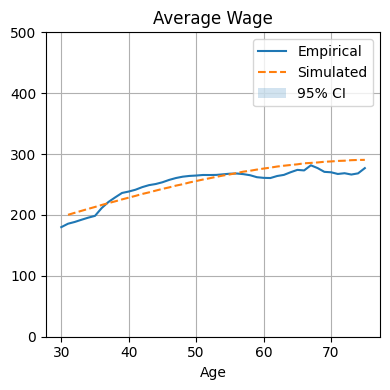

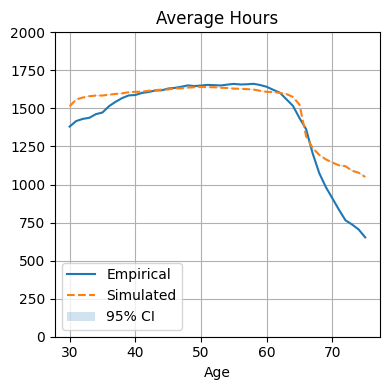

In [31]:
edu = df_edu.copy().loc[df_edu.age <= 75]       # empirical
moments_sim = compute_simulation_moments_with_ci(sim, start_age, hours_map)  # Call the function
# Ensure moments_sim.age is a pandas Series before filtering
moments_sim = moments_sim.loc[pd.Series(moments_sim.age) <= 75]  # Filter simulated + CIs
# scale avg_wealth by 100_000


# print plots
plot_empirical_vs_simulated_with_ci(
    edu = edu,
    moments_sim = moments_sim,
    out_subfolder="wage_estimation",
    var_labels=labels,
    var_scales=scales,
    ylims={"avg_wealth": (0, 3_000_000), "avg_hours": (0, 2_000), "prob_work": (0, 1), "hours_0": (0, 1), "hours_1": (0, 1), "hours_2": (0, 1), "hours_3": (0, 1), "hours_4": (0, 1), "avg_wage": (0,500) },
)

# Conclusion

There is absolutely no change in average wage when moving from OLS estimation to WLS estimation of the wage parameters